Este notebook es el que usaremos para poder entrenar especificamente los modelos en base al dataset que vamos a usar que es el de libros, de este notebook van a salir las graficas que usaremos para el front end, y las funciones 

Nos vamos a centrar en completar una primera fase que seria preprocesar el dataset de libros:
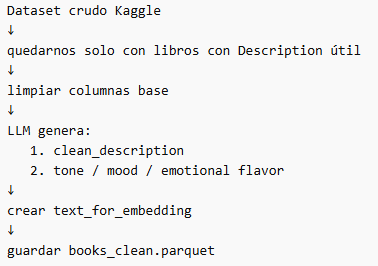

Para los embeddings vamos a juntar el titulo, la descripcion y la categoria, solo que en este caso usaremos una descripcion creada por un LLM mas limpia que la original y mas pequena, vamos a generar un Mood Label o Tone label tambien.

In [16]:
pip install kagglehub pandas numpy pyarrow tqdm openai tenacity -q

Note: you may need to restart the kernel to use updated packages.


Bajamos el dataset de kaggle y definimos algunos imports

In [17]:
import os
import json
import glob
import re
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import kagglehub

DATASET_ID = "elvinrustam/books-dataset"

path = kagglehub.dataset_download(DATASET_ID)
print("Dataset path:", path)

files = glob.glob(os.path.join(path, "**", "*"), recursive=True)
for f in files[:30]:
    print(f)

Dataset path: C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3
C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3\BooksDataset.csv
C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3\BooksDatasetClean.csv


Crear el csv con el dataset que bajamos de kaggle, para este caso kaggle traia 2 uno clean y uno raw que son lo mismo en informacion solo que la fecha esta procesada diferente y el precio


In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import os
import json

dataset_path = Path(path)

clean_csv = dataset_path / "BooksDatasetClean.csv"

df_raw = pd.read_csv(clean_csv)

print("Using:", clean_csv)
print("Shape:", df_raw.shape)
df_raw.head()

Using: C:\Users\user\.cache\kagglehub\datasets\elvinrustam\books-dataset\versions\3\BooksDatasetClean.csv
Shape: (103063, 8)


,Title,Authors,Description,Category,Publisher,Price Starting With ($),Publish Date (Month),Publish Date (Year)
0,Goat Brothers,"By Colton, Larry",NaN,"History , General",Doubleday,8.79,January,1993
1,The Missing Person,"By Grumbach, Doris",NaN,"Fiction , General",Putnam Pub Group,4.99,March,1981
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",NaN,"Cooking , Reference",Workman Pub Co,4.99,September,1983
3,When Your Corporate Umbrella Begins to Leak: A Handbook for White Collar Re-Employment,"By Davis, Paul D.",NaN,NaN,Natl Pr Books,4.99,April,1991
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",NaN,NaN,Amy Spangler,5.32,February,1997


Vamos a normalizar los nombres de las columnas para no tener espacios y mayusculas y no batallar 

In [19]:
df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("$", "usd", regex=False)
)

print(df.columns.tolist())
df.head()

['title', 'authors', 'description', 'category', 'publisher', 'price_starting_with_usd', 'publish_date_month', 'publish_date_year']


,title,authors,description,category,publisher,price_starting_with_usd,publish_date_month,publish_date_year
0,Goat Brothers,"By Colton, Larry",NaN,"History , General",Doubleday,8.79,January,1993
1,The Missing Person,"By Grumbach, Doris",NaN,"Fiction , General",Putnam Pub Group,4.99,March,1981
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",NaN,"Cooking , Reference",Workman Pub Co,4.99,September,1983
3,When Your Corporate Umbrella Begins to Leak: A Handbook for White Collar Re-Employment,"By Davis, Paul D.",NaN,NaN,Natl Pr Books,4.99,April,1991
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",NaN,NaN,Amy Spangler,5.32,February,1997


Definimos las columnas principales, para tenerlas en variable

In [20]:
COL_TITLE = "title"
COL_AUTHORS = "authors"
COL_DESC = "description"
COL_CATEGORY = "category"
COL_PUBLISHER = "publisher"
COL_PRICE = "price_starting_with_usd"
COL_MONTH = "publish_date_month"
COL_YEAR = "publish_date_year"

Aqui vamos a implementar una limpieza basica del texto, quitar espacios repetidos, html, etc.

In [21]:
def clean_basic_text(x):
    if pd.isna(x):
        return ""
    
    x = str(x)
    x = re.sub(r"<.*?>", " ", x)          # quitar HTML
    x = re.sub(r"\s+", " ", x).strip()    # espacios repetidos
    return x

df["title_clean"] = df[COL_TITLE].apply(clean_basic_text)
df["authors_clean"] = df[COL_AUTHORS].apply(clean_basic_text)
df["description_original_clean"] = df[COL_DESC].apply(clean_basic_text)
df["category_clean"] = df[COL_CATEGORY].apply(clean_basic_text)
df["publisher_clean"] = df[COL_PUBLISHER].apply(clean_basic_text)

df[[
    "title_clean",
    "authors_clean",
    "description_original_clean",
    "category_clean",
    "publisher_clean"
]].head()

,title_clean,authors_clean,description_original_clean,category_clean,publisher_clean
0,Goat Brothers,"By Colton, Larry",,"History , General",Doubleday
1,The Missing Person,"By Grumbach, Doris",,"Fiction , General",Putnam Pub Group
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",,"Cooking , Reference",Workman Pub Co
3,When Your Corporate Umbrella Begins to Leak: A Handbook for White Collar Re-Employment,"By Davis, Paul D.",,,Natl Pr Books
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",,,Amy Spangler


Ahora lo importante, vamos a solo quedarnos con libros que tienen una descripcion util, no nulos, no si no tienen nada, etc. Porque para este problema necesitamos que los libros tengan descripcion porque lo necesitamos para la core function de nuestro sistema, para que los embeddings tengan sentido, y a parte se las pasaremos a un LLM para que nos cree una descripcion mas limpia y compacta, y no le podemos pasar valores nulos.

In [22]:
bad_patterns = [
    r"^\s*$",
    r"^null$",
    r"^none$",
    r"^nan$",
    r"for ingest only",
    r"description unavailable",
    r"no description",
    r"not available"
]

bad_regex = re.compile("|".join(bad_patterns), re.IGNORECASE)

def is_valid_description(desc, min_chars=80):
    if not desc:
        return False
    
    if bad_regex.search(desc):
        return False
    
    if len(desc) < min_chars:
        return False
    
    alpha_count = sum(ch.isalpha() for ch in desc)
    if alpha_count < 40:
        return False
    
    return True

before = len(df)

df = df[df["title_clean"].str.len() > 0].copy()
df = df[df["description_original_clean"].apply(is_valid_description)].copy()

after = len(df)

print("Rows before filtering:", before)
print("Rows after filtering:", after)
print("Rows removed:", before - after)
print("Remaining percentage:", round(after / before * 100, 2), "%")

Rows before filtering: 103063
Rows after filtering: 69386
Rows removed: 33677
Remaining percentage: 67.32 %


Vamos a limpiar los libros que tengan datos como Unkown, para despues descartarlos tambien

In [23]:
df["authors_clean"] = df["authors_clean"].replace("", "Unknown")
df["category_clean"] = df["category_clean"].replace("", "Unknown")
df["publisher_clean"] = df["publisher_clean"].replace("", "Unknown")

df["price_clean"] = df[COL_PRICE]
df["publish_month_clean"] = df[COL_MONTH]
df["publish_year_clean"] = df[COL_YEAR]

df[[
    "title_clean",
    "authors_clean",
    "category_clean",
    "publisher_clean",
    "price_clean",
    "publish_month_clean",
    "publish_year_clean"
]].head()

,title_clean,authors_clean,category_clean,publisher_clean,price_clean,publish_month_clean,publish_year_clean
7,Journey Through Heartsongs,"By Stepanek, Mattie J. T.","Poetry , General",VSP Books,19.96,September,2001
8,In Search of Melancholy Baby,"By Aksyonov, Vassily, Heim, Michael Henry, and Bouis, Antonina W.","Biography & Autobiography , General",Random House,4.99,June,1987
10,The Dieter's Guide to Weight Loss During Sex,"By Smith, Richard","Health & Fitness , Diet & Nutrition , Diets",Workman Publishing Company,4.99,January,1978
11,Germs : Biological Weapons and America's Secret War,"By Miller, Judith, Engelberg, Stephen, and Broad, William J.","Technology & Engineering , Military Science",Simon & Schuster,4.99,October,2001
13,The Good Book: Reading the Bible with Mind and Heart,"By Gomes, Peter J.","Religion , Biblical Biography , General",Harper Perennial,5.29,May,1998


Quitamos los registros que esten duplicados

In [24]:
before = len(df)

df = df.drop_duplicates(
    subset=["title_clean", "authors_clean", "description_original_clean"]
).reset_index(drop=True)

after = len(df)

print("Rows before duplicates:", before)
print("Rows after duplicates:", after)
print("Duplicates removed:", before - after)

Rows before duplicates: 69386
Rows after duplicates: 68978
Duplicates removed: 408


Ahora si vamos a visualizar algunos ejemplos de descripciones para poder ver si son muy largas, o con que estamos trabajando, para ver si es necesario pasarselas a un LLM para que nos cree la version clean. 

In [25]:
pd.set_option("display.max_colwidth", 700)

sample = df[[
    "title_clean",
    "authors_clean",
    "category_clean",
    "description_original_clean"
]].sample(10, random_state=42)

sample

,title_clean,authors_clean,category_clean,description_original_clean
16355,Protecting the Gift: Keeping Children and Teenagers Safe (and Parents Sane),"By De Becker, Gavin","Family & Relationships , Parenting , General","A leading authority on human violence and author of The Gift of Fear shares practical advice on how parents can protect their children from being victimized, explains how to eliminate danger, and discusses such topics as school safety, teenage dating, and firearms. Tour."
65860,The Food and Drink of Mexico,"By Booth, George C.","Cooking , Regional & Ethnic , Mexican","This book will show you how to make your own enchiladas, tacos, guacamole, refried beans, chili con carne, and tamales. It will also show you how to make outstanding soups, elaborate main dishes, unusual vegetables, and more, with a total of 198 excellent culinary recipes from all over Mexico. Whatever you make from this cookbook you are sure to find delicious.Choose from such mouth-watering dishes as meat ball soup, rice soup, chick pea pottage, summer squash soup, sopa Mexicana, Mexican meat loaf, roast pork loin with mushrooms, steak with bananas, estofado, beef and vegetables (guisado de res), green pot stew, Totonac potluck, herb pork barbecue, Mexican-style chicken, turkey with mol..."
12074,Golf For Women: Easy-to-follow Instruction from Pro Golf's Leading Tournament Winner,"By Whitworth, Kathy and Glenn, Rhonda","Sports & Recreation , Golf","Women golfers will find the ideal teacher in Kathy Whitworth, winner of eighty-eight professional tournaments--more than any woman or man in golf history. In Golf for Women, she shares her theories, skills, and experiences derived from over 30 years of playing and teaching.Illustrated with 120 instructional photographs, Golf for Women is simple enough for a beginner, but offers advice and techniques that advanced players can use. Each chapter cover a specific fundamental or shot, taking the reader from tee to green in an orderly fashion. Topics include:The fundamentals of the Golf Swing: Grip, alignment, stance hand positions and moreDriving: how to add distance without slicing the ballT..."
11639,Brush Up Your Classics!,"By MacRone, Michael and Lulevitch, Tom (ILT)","Reference , Personal & Practical Guides","Here is a fabulous and fun reference guide to the Latin and Greek origins of such words and expressions as ""windbag"" and ""seize the day,"" as well as a lively tour through the literature and life of ancient times. With fun black-and-white illustrations, this irreverent and informative book provides history, maps, and even a glossary for a unique way to revisit the ancient classics."
46141,Absolution by Murder (A Sister Fidelma Mystery) (Mystery of Ancient Ireland),"By Tremayne, Peter","Fiction , Mystery & Detective , General","The King of Northumbria has requested the services of a wise counsel to decide the people's religious future. Among the select priests, elders, and scholars from Ireland and Rome is Sister Fidelma of Kildare. Trained as an advocate of the courts, she was expecting to rule on issues of law. Instead she was plunged into unholy murder.Dead was the Abbess étain, a leading Celtic speaker, her throat slashed. With the counsel in an uproar and civil war threatening, the desperate king has turned to the sharp-witted Sister Fidelma for help. With the aide of her dear friend Brother Eadulf and her faith in the truth, she must act in haste before the killer strikes again."
20882,I Still Miss My Man but My Aim Is Getting Better,"By Shankman, Sarah","Fiction , Mystery & Detective , General","Tuesday, eleven-thirty, a bright spring morning .... Just off the breakfast shift at Sweet Willie's meat-and-three, Shelby Kay Tate rushes down an old-fashioned Nashville sidewalk with Thursday night playing itself out in her mind. It's songwriters' night at the Sutler, a chance to serve up her big, bluesy voice to a crowd hungry for new country songs. Shelby's picturing herself onstage, a girl f

Si, definitivamente las descripciones son muy largas, necesitamos pasarselas a un LLM para que nos la normalize creandonos descripciones con un limite de palabras, compactas pero que aun asi capture la esencia del texto para que quede bien para los embeddings.

Vamos a ver la distribucion de las descripciones

In [26]:
df["description_length"] = df["description_original_clean"].str.len()

df["description_length"].describe()

count    68978.000000
mean       741.461654
std        649.920947
min         80.000000
25%        226.000000
50%        586.000000
75%       1060.000000
max      23502.000000
Name: description_length, dtype: float64

In [29]:
df[[
    "title_clean",
    "category_clean",
    "description_length",
    "description_original_clean"
]].sort_values("description_length").head(3)

,title_clean,category_clean,description_length,description_original_clean
34721,The Wit's Dictionary,Unknown,80,A collection of humorous definitions for words commonly heard and used every day
35290,The 11th Hour: The Official Strategy Guide (Secrets of the Games Series) (Pt. 2),"Games , Video & Electronic",80,Detailed puzzle strategies and solutionsLocations of all the treasure hunt items
25395,Scholastic Reader Level 2: Wake Me in Spring!,"Juvenile Fiction , Social Themes , Friendship",80,Bear is getting very sleepy. But Mouse thinks Bear should stay awake for winter!


In [30]:
df[[
    "title_clean",
    "category_clean",
    "description_length",
    "description_original_clean"
]].sort_values("description_length", ascending=False).head(3)

,title_clean,category_clean,description_length,description_original_clean
43822,Blood of Paradise,"Fiction , General",23502,"El Salvador: America’s great Cold War success story and the model for Iraq’s fledgling democracy–if one ignores the grinding poverty, the corruption, the spiraling crime, and a murder rate ranked near the top in the hemisphere. This is where Jude McManus works as an executive protection specialist, currently assigned to an American engineer working for a U.S. consortium.Ten years before, at age seventeen, he saw his father and two Chicago cop colleagues arrested for robbing street dealers. The family fell apart in the scandal’s wake, his disgraced dad died under suspicious circumstances, and Jude fled Chicago to join the army and forge a new life.Now the past returns when one of his fath..."
6668,The Sixteen Pleasures: A Novel,"Fiction , Historical , General",14977,"Chapter OneWhere I Want to BeI was twenty-nine years old when the Arno flooded its banks on Friday 4 November 1966. According to the Sunday New York Times the damage wasn't extensive, but by Monday it was clear that Florence was a disaster. Twenty feet of water in the cloisters of Santa Croce, the Cimabue crucifix ruined beyond hope of restoration, panels ripped from the Baptistry doors, the basement of the Biblioteca Nazionale completely underwater, hundreds of thousands of volumes waterlogged, the Archivio di Stato in total disarray. On Tuesday I decided to go to Italy, to offer my services as a humble book conservator, to help in any way I could, to save whatever could be saved, inclu..."
20131,An Accidental American: A Novel (Mortalis),"Fiction , Thrillers , General",12456,"Forced out of a self-imposed exile, one woman faces a lifetime’s worth of secrets and betrayal–all in the name of staying alive. Nicole Blake had planned to leave her criminal life in the past. She had done her time in a dank prison in Marseille and relinquished the world of forgery and counterfeiting for an unassuming career as a freelance consultant. Now her world is a small farm in the French Pyrenees, with daily fresh eggs and the companionship of her devoted dog.But when U.S. intelligence operative John Valsamis shows up at her door, Nicole is reminded that she’ll always be an ex-con. Valsamis is after Nicole’s former lover, Rahim Ali, and soon Nicole finds herself back in Lisbon, t..."
